
***Import Libraries***

In [1]:
from symfit import parameters, variables, sin, cos, Fit
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Reading Data**

*For X direction*

In [2]:
df3= pd.read_csv('freq_x_rot.csv', header = 0)

x_angle = df3['angle']
x_angle = x_angle*np.pi/180.
f_sx = df3['fre_sum']/1E3
f_dx = df3['freq_diff']/1E6
f_1Dx = df3['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dx = df3['freq_2D']/1E6 #freq of |0> -> |-1>


*For Y direction*

In [3]:
df2= pd.read_csv('freq_y_rot.csv', header = 0)


f_sy = df2['fre_sum']/1E3
f_dy= df2['freq_diff']/1E6
f_1Dy = df2['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dy = df2['freq_2D']/1E6 #freq of |0> -> |-1>

*For Z direction*

In [4]:
df1 = pd.read_csv('freq_z_rot.csv', header = 0)

f_sz = df1['fre_sum']/1E3
f_dz= df1['freq_diff']/1E6
f_1Dz = df1['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dz = df1['freq_2D']/1E6 #freq of |0> -> |-1>

***Plotting all frequency data***

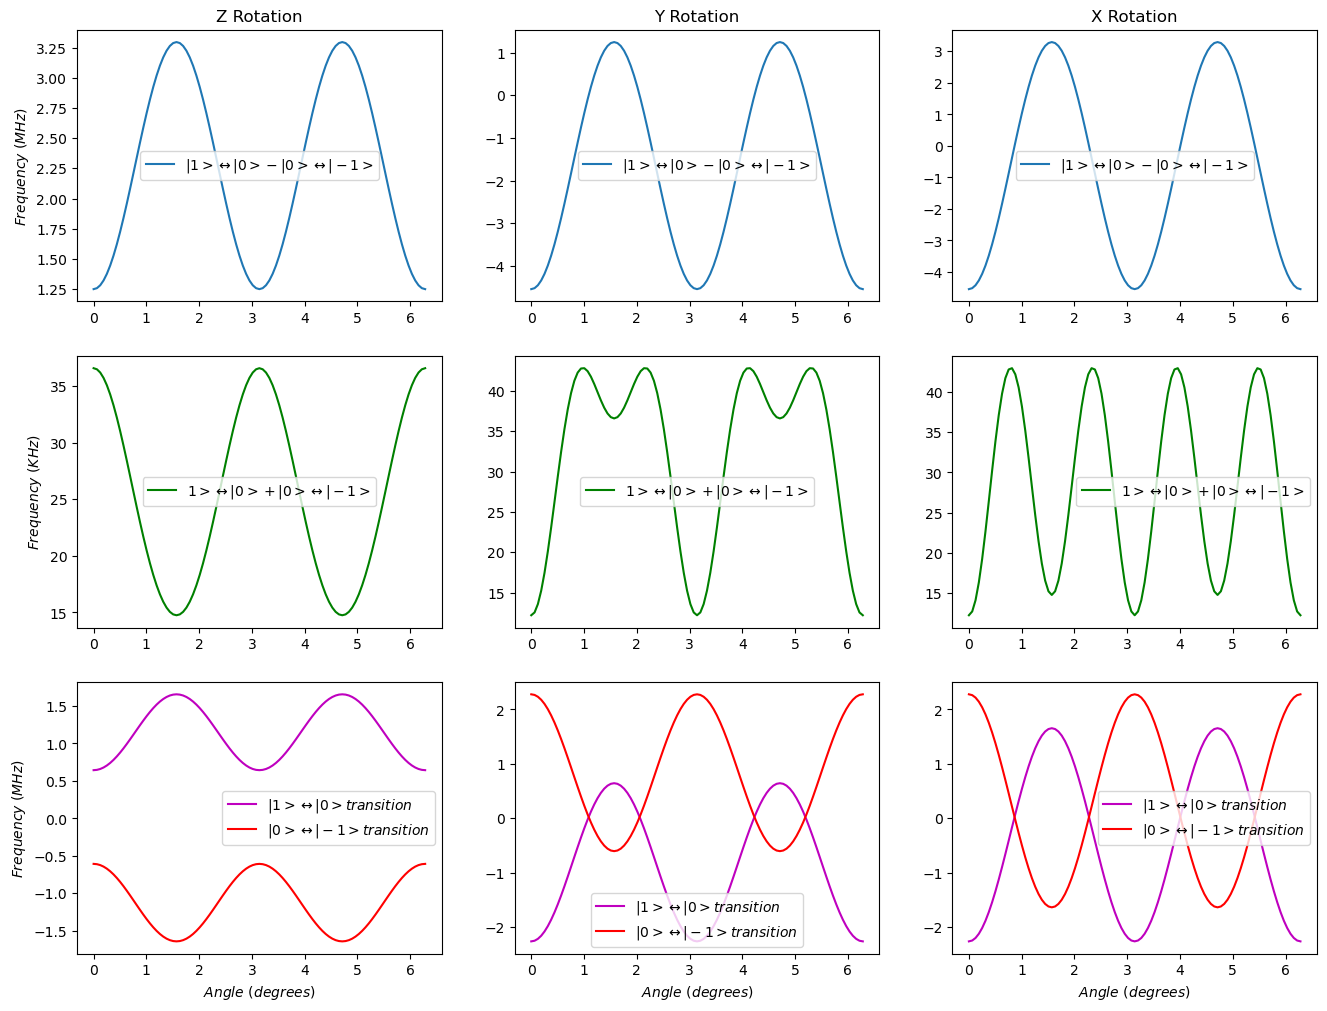

In [5]:
fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(16,12))

# input from z rot file

axes[0,0].plot(x_angle,f_dz, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,0].set_title('Z Rotation')
#axes[0,0].set_ylabel(r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$' + '\n' + 'frequency(Hz)')
axes[0,0].set_ylabel(r'$Frequency\ (MHz)$')
axes[0,0].legend()

axes[1,0].plot(x_angle,f_sz, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
#axes[1,0].set_ylabel(r'$|1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$' + '\n' + 'frequency(KHz)')
axes[1,0].set_ylabel(r'$Frequency\ (KHz)$')
axes[1,0].legend()

axes[2,0].plot(x_angle,f_1Dz, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,0].plot(x_angle,f_2Dz, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,0].set_ylabel(r'$Frequency\ (MHz)$')
axes[2,0].set_xlabel(r'$Angle\ (degrees)$')
axes[2,0].legend()

# input from y rot file

axes[0,1].plot(x_angle,f_dy, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,1].set_title('Y Rotation')
axes[0,1].legend()
axes[1,1].plot(x_angle,f_sy, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
axes[1,1].legend()

axes[2,1].plot(x_angle,f_1Dy, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,1].plot(x_angle,f_2Dy, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,1].set_xlabel(r'$Angle\ (degrees)$')
axes[2,1].legend()

# input from x rot file

axes[0,2].plot(x_angle,f_dx, '-', label = r'$|1>\leftrightarrow|0> - |0>\leftrightarrow|-1>$')
axes[0,2].set_title('X Rotation')
axes[0,2].legend()

axes[1,2].plot(x_angle,f_sx, '-g', label = r'$1>\leftrightarrow|0> + |0>\leftrightarrow|-1>$')
axes[1,2].legend()

axes[2,2].plot(x_angle,f_1Dx, '-m', label = r'$|1>\leftrightarrow|0> transition$')
axes[2,2].plot(x_angle,f_2Dx, '-r',label = r'$|0>\leftrightarrow|-1> transition$')
axes[2,2].set_xlabel(r'$Angle\ (degrees)$')
axes[2,2].legend()

In [6]:
# #fitting functions
# def Hcsa1(theta,A1, B1, C1):
    
#     freq_csa1 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180)
#     return freq_csa1

# def HQ2 (theta,A1, B1, C1, D1, E1):
#     freq_Q2 = A1 + B1*np.cos(2*theta*np.pi/180) + C1*np.sin(2*theta*np.pi/180) + D1*np.cos(4*theta*np.pi/180) + E1*np.sin(4*theta*np.pi/180) 
#     return freq_Q2

**Defining Fourier Series**

In [7]:

def fourier_series(x, f, n=0):
    """
    Returns a symbolic fourier series of order `n`.

    :param n: Order of the fourier series.
    :param x: Independent variable
    :param f: Frequency of the fourier series
    """
    # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, n + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, n + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * f * x ) + bi * sin(i * f * x )
                     for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series

x, y = variables('x, y')
w, = parameters('w')



Note: Fitting can be done using the same function. The terms can be ignored according to the fitting function provided in NMR theory.

***Fitting for X rotation***

In [8]:
fx_s_float = np.array(f_sx, dtype=float) #sum frequency
fx_d_float = np.array(f_dx, dtype = float) #difference frequency
x_float = np.array(x_angle, dtype = float)
# x= np.asarray(x)
# y_sx=np.asarray(y_sx)
# type(x)

Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.824642e+01 2.851711e-14
a1        -1.264300e+00 4.219839e-14
a2        -1.475996e+01 3.921773e-14
b1        -1.013931e-13 3.967097e-14
b2        2.287878e-13 8.517701e-14
w         2.000000e+00 8.135025e-16
Status message         Optimization terminated successfully.
Number of iterations   27
Objective              <symfit.core.objectives.LeastSquares object at 0x7f1fc1f92530>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f1fc1f91870>

Goodness of fit qualifiers:
chi_squared            7.42589164420006e-24
objective_value        3.71294582210003e-24
r_squared              1.0


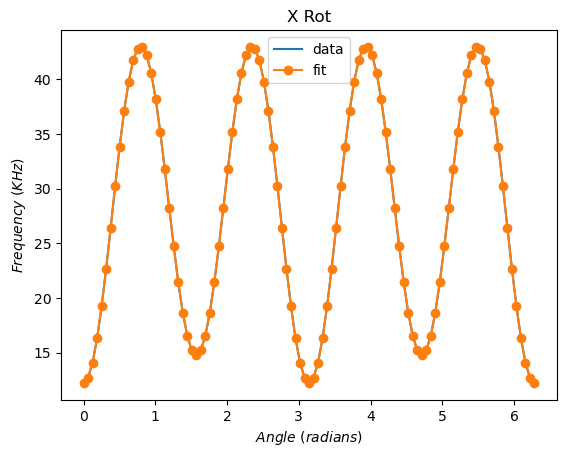

In [20]:

#providing data
xdata = x_float
ydata = fx_s_float

#Generate Fit function
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.title('X Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        -6.252297e-01 3.037347e-05
a1        2.021456e-04 5.891324e-05
a2        -3.920024e+00 3.564501e-05
b1        1.223085e-08 3.513995e-05
b2        -4.743564e-04 1.207823e-04
w         1.000019e+00 4.691732e-06
Status message         Optimization terminated successfully.
Number of iterations   35
Objective              <symfit.core.objectives.LeastSquares object at 0x7f1fc204b9a0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f1fc2049780>

Goodness of fit qualifiers:
chi_squared            5.865264363004119e-06
objective_value        2.9326321815020596e-06
r_squared              0.99999999251456


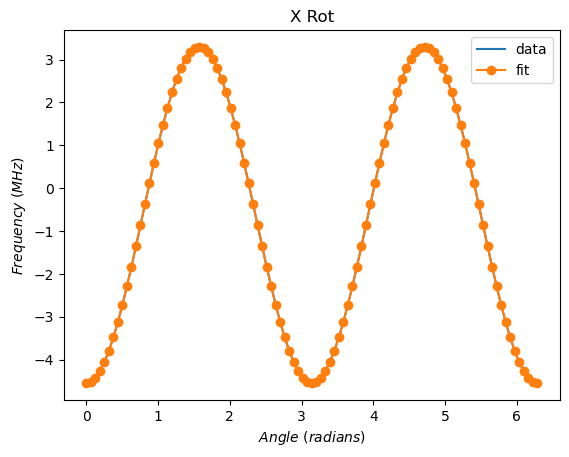

In [25]:
#Providing data
xdata = x_float
ydata = fx_d_float

#Generating Fit function
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.title('X Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (MHz)$')
plt.legend()
plt.show()

***Fitting for Y rotation***

In [11]:
fy_s_float = np.array(f_sy, dtype=float) #sum frequency
fy_d_float = np.array(f_dy, dtype=float) #difference frequency


Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        3.245884e+01 2.202122e-14
a1        -1.217312e+01 3.079824e-14
a2        -8.063570e+00 2.862967e-14
b1        3.623988e-14 4.395338e-14
b2        -1.123842e-14 5.256844e-14
w         2.000000e+00 8.677151e-16
Status message         Optimization terminated successfully.
Number of iterations   34
Objective              <symfit.core.objectives.LeastSquares object at 0x7f1fc412f070>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f1fc412c220>

Goodness of fit qualifiers:
chi_squared            3.9459264241261934e-24
objective_value        1.9729632120630967e-24
r_squared              1.0


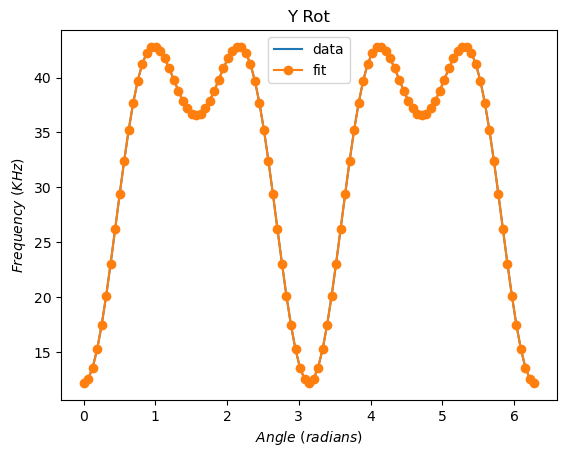

In [29]:
#Providing data
xdata = x_float
ydata = fy_s_float

#Generating Fit Fucntion
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.title('Y Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        -1.647726e+00 1.699391e-05
a1        1.131009e-04 3.296215e-05
a2        -2.897416e+00 1.994127e-05
b1        -4.570693e-10 1.966033e-05
b2        2.434501e-05 6.757700e-05
w         1.000015e+00 3.551484e-06
Status message         Desired error not necessarily achieved due to precision loss.
Number of iterations   34
Objective              <symfit.core.objectives.LeastSquares object at 0x7f1fc1e4ded0>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f1fc1e4e200>

Goodness of fit qualifiers:
chi_squared            1.8359842029804156e-06
objective_value        9.179921014902078e-07
r_squared              0.9999999957109992


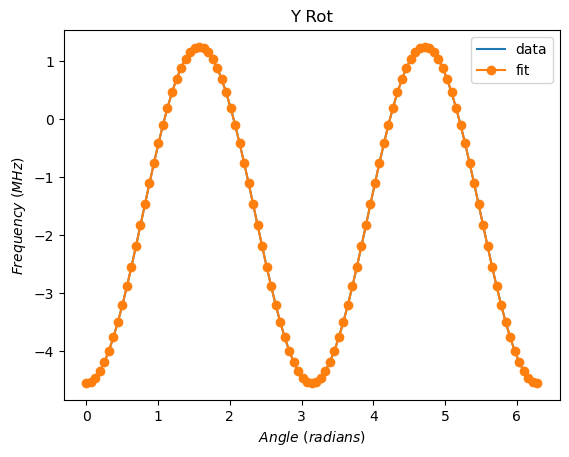

In [13]:
#Proving data
xdata = x_float
ydata = fy_d_float

#genearting fit function
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.title('Y Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (MHz)$')
plt.legend()
plt.show()

***Fitting For Z rotation***

In [14]:
fz_s_float = np.array(f_sz, dtype=float) #sum frequency
fz_d_float = np.array(f_dz, dtype = float) #difference frequency

Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + b1*sin(w*x) + b2*sin(2*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.532475e+01 3.765939e-14
a1        1.090882e+01 4.896842e-14
a2        3.348195e-01 4.929854e-14
b1        -1.573856e-13 1.079976e-13
b2        3.650653e-13 4.903092e-14
w         2.000000e+00 2.813098e-15
Status message         Optimization terminated successfully.
Number of iterations   31
Objective              <symfit.core.objectives.LeastSquares object at 0x7f1fc1a78490>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f1fc1a78430>

Goodness of fit qualifiers:
chi_squared            1.1252791579502887e-23
objective_value        5.6263957897514434e-24
r_squared              1.0


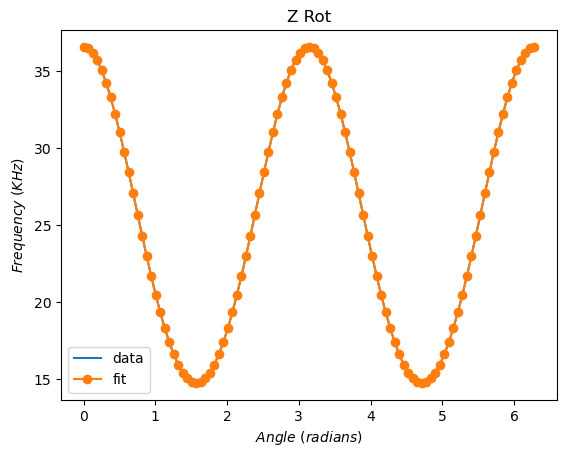

In [30]:
#Providing data

xdata = x_float
ydata = fz_s_float

#generating fit function
model_dict = {y: fourier_series(x, f=w, n=2)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.title('Z Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (KHz)$')
plt.legend()
plt.show()

Fitting Function: {y: a0 + a1*cos(w*x) + a2*cos(2*w*x) + a3*cos(3*w*x) + a4*cos(4*w*x) + b1*sin(w*x) + b2*sin(2*w*x) + b3*sin(3*w*x) + b4*sin(4*w*x)}
Fit result:
 
Parameter Value        Standard Deviation
a0        2.272488e+00 7.520838e-14
a1        5.113125e-06 1.895105e-13
a2        -1.022625e+00 5.334571e-14
a3        -5.113125e-06 1.225547e-13
a4        1.167071e-05 6.507719e-14
b1        -1.022625e-05 4.268986e-14
b2        -1.163234e-12 4.434867e-13
b3        -1.022625e-05 4.268987e-14
b4        3.798341e-14 4.268987e-14
w         1.000000e+00 6.870109e-14
Status message         Optimization terminated successfully.
Number of iterations   40
Objective              <symfit.core.objectives.LeastSquares object at 0x7f1ff0450250>
Minimizer              <symfit.core.minimizers.BFGS object at 0x7f1ff04532b0>

Goodness of fit qualifiers:
chi_squared            8.292031779583045e-24
objective_value        4.1460158897915224e-24
r_squared              1.0


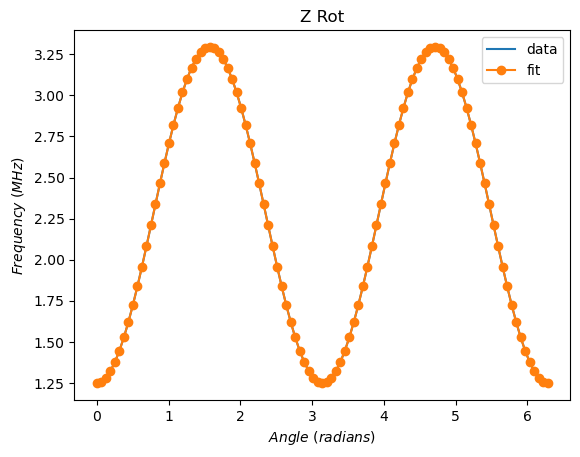

In [36]:
#Providing data

xdata = x_float
ydata = fz_d_float

#Generating Fit function
model_dict = {y: fourier_series(x, f=w, n=4)}

# Define a Fit object for this model and data
fit = Fit(model_dict, x=xdata, y=ydata)
fit_result = fit.execute()
print('Fitting Function:',model_dict)
print('Fit result:''\n',fit_result)

# Plot the result
plt.plot(xdata, ydata, label = "data")
plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
plt.title('Z Rot')
plt.xlabel(r'$Angle\ (radians)$')
plt.ylabel(r'$Frequency\ (MHz)$')
plt.legend()
plt.show()

In [51]:
print(fit_result.params['a1'])

5.113125237885449e-06


In [17]:
fz_float = np.array(f_sz, dtype=float)
fzd_float = np.array(f_dz, dtype = float)

data = np.vstack([fz_float, fzd_float])

In [18]:
data[1]

array([1.249875  , 1.25793586, 1.28199647, 1.32167747, 1.37635315,
       1.44516136, 1.52701708, 1.62062953, 1.72452251, 1.83705767,
       1.95646036, 2.08084758, 2.2082577 , 2.33668137, 2.46409323,
       2.58848383, 2.70789133, 2.82043248, 2.92433227, 3.01795196,
       3.09981494, 3.16863002, 3.2233118 , 3.2629978 , 3.28706205,
       3.295125  , 3.28705949, 3.26299275, 3.22330441, 3.16862048,
       3.09980351, 3.01793894, 2.92431801, 2.82041735, 2.70787571,
       2.58846809, 2.46407775, 2.33666649, 2.20824373, 2.08083478,
       1.95644893, 1.83704776, 1.72451419, 1.62062282, 1.52701192,
       1.44515764, 1.3763507 , 1.32167606, 1.28199584, 1.2579357 ,
       1.249875  , 1.25794081, 1.28200593, 1.32169085, 1.37636978,
       1.44518051, 1.52703796, 1.62065134, 1.72454446, 1.83707901,
       1.9564804 , 2.08086574, 2.20827349, 2.33669444, 2.46410336,
       2.58849096, 2.70789554, 2.82043399, 2.92433143, 3.01794925,
       3.09981094, 3.16862538, 3.22330723, 3.26299403, 3.28705

In [19]:
for i in range(0, 1):
    xdata = x_float
    ydata = data

    # Define a Fit object for this model and data
    fit[i] = Fit(model_dict, x=xdata, y=ydata[i])
    fit_result = fit.execute()
    print('Fitting Function:',model_dict)
    print('Fit result:''\n',fit_result)

    # Plot the result
    plt.plot(xdata, ydata[i], label = "data")
    plt.plot(xdata, fit.model(xdata, **fit_result.params).y, marker="o", label = "fit")
    plt.title('Y Rot')
    plt.xlabel(r'$Angle\ (radians)$')
    plt.ylabel(r'$Frequency\ (KHz)$')
    plt.legend()
    plt.show()
    


TypeError: 'Fit' object does not support item assignment